Libraries loaded successfully!
Please upload IMDB Dataset.csv


Saving IMDB Dataset.csv to IMDB Dataset.csv
Dataset loaded!
Extracting features (this may take a few minutes)...
Feature extraction complete!
Feature shape: (50000, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7316 - loss: 0.5393 - val_accuracy: 0.7682 - val_loss: 0.4771
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7728 - loss: 0.4894 - val_accuracy: 0.7740 - val_loss: 0.4747
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7727 - loss: 0.4842 - val_accuracy: 0.7735 - val_loss: 0.4754
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7714 - loss: 0.4859 - val_accuracy: 0.7675 - val_loss: 0.4776
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7723 - loss: 0.4896 - val_accuracy: 0.7722 - val_loss: 0.4757
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7706 - loss: 0.4859 - val_accuracy: 0.7747 - val_loss: 0.4743
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7743 - loss: 0.4772 - val_accuracy: 0.7768 - val_loss: 0.4736
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7734 - loss: 0.4819 - 

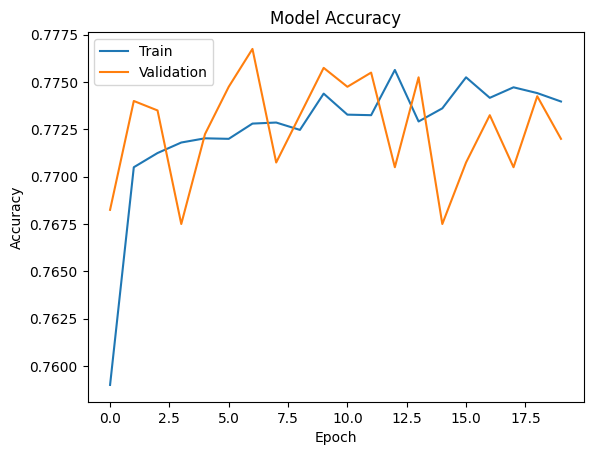

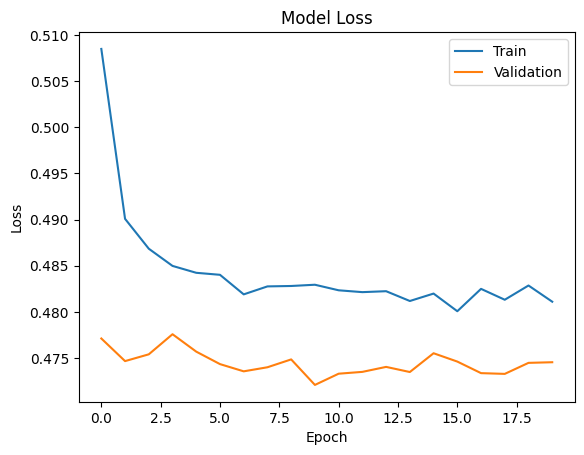

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Everything completed successfully!


In [2]:
# ==========================================================
# IMDB Sentiment Classification using MLP
# Features: VADER + TextBlob Polarity
# ==========================================================

# -----------------------------
# 1. Install Required Libraries
# -----------------------------
!pip install vaderSentiment textblob --quiet

# -----------------------------
# 2. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("Libraries loaded successfully!")

# -----------------------------
# 3. Upload Dataset
# -----------------------------
print("Please upload IMDB Dataset.csv")
uploaded = files.upload()

df = pd.read_csv("IMDB Dataset.csv")
print("Dataset loaded!")
df.head()

# -----------------------------
# 4. Prepare Labels
# -----------------------------
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# -----------------------------
# 5. Feature Extraction
# -----------------------------
analyzer = SentimentIntensityAnalyzer()

def extract_features(text):
    vader_scores = analyzer.polarity_scores(text)
    textblob_score = TextBlob(text).sentiment.polarity

    return [
        vader_scores['compound'],
        vader_scores['pos'],
        vader_scores['neg'],
        vader_scores['neu'],
        textblob_score
    ]

print("Extracting features (this may take a few minutes)...")
X = np.array([extract_features(review) for review in df['review']])
y = df['sentiment'].values

print("Feature extraction complete!")
print("Feature shape:", X.shape)

# -----------------------------
# 6. Normalize Features
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 7. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 8. Build MLP Model
# -----------------------------
model = Sequential([
    Dense(32, activation='relu', input_shape=(5,)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 9. Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# 10. Evaluate Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 11. Plot Training Curves
# -----------------------------
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# -----------------------------
# 12. Save Model
# -----------------------------
model.save("mlp_sentiment_model.h5")
files.download("mlp_sentiment_model.h5")

# -----------------------------
# 13. Save Evaluation Results
# -----------------------------
with open("evaluation_metrics.txt", "w") as f:
    f.write(f"Test Accuracy: {accuracy}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))
    f.write("\nConfusion Matrix:\n")
    f.write(str(confusion_matrix(y_test, y_pred)))

files.download("evaluation_metrics.txt")

print("\nEverything completed successfully!")
